# Étude des décimales de $\pi$ et construction d'un générateur uniforme

Ce notebook reprend le script du projet sous une forme plus pédagogique. L'objectif est qu'une personne qui n'a pas vu l'énoncé puisse comprendre :

- ce que l'on teste ;
- quelles sont les hypothèses statistiques ;
- comment le générateur basé sur $\pi$ est construit ;
- comment les résultats sont interprétés.

On ne cherche pas à établir un hasard véritable. On vérifie seulement si les observations sont compatibles avec certains comportements attendus d'une suite pseudo-aléatoire.

## Dépendances

Le notebook utilise :

- `scipy` pour les p-values des tests statistiques ;
- `matplotlib` pour les figures ;
- `random` pour le générateur Python de comparaison.

Si nécessaire :

```bash
python3 -m pip install -r requirements.txt
```

In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
from scipy.stats import chisquare, kstest

ALPHA = 0.05
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)
(FIGURES_DIR / "gap_tests").mkdir(exist_ok=True)

def conclusion(p_value, alpha=ALPHA):
    """Conclusion correcte au seuil choisi."""
    if p_value < alpha:
        return f"On rejette H0 au seuil de {alpha * 100:.0f}%."
    return f"On ne rejette pas H0 au seuil de {alpha * 100:.0f}%."

## 1. Chargement des décimales de $\pi$

Le fichier `pi.txt` contient les décimales de $\pi$. On conserve uniquement les chiffres. Si le fichier commence par `3.`, on retire le premier chiffre `3` afin d'étudier seulement les décimales.

In [2]:
def load_pi_digits(filepath="pi.txt"):
    """Charge les décimales de pi sous forme de liste d'entiers."""
    text = Path(filepath).read_text(encoding="utf-8")
    digits = [int(char) for char in text if char.isdigit()]

    # Le fichier commence souvent par 3. On ne garde que les décimales.
    if digits and digits[0] == 3:
        digits = digits[1:]

    return digits

digits = load_pi_digits("pi.txt")
print(f"Nombre de décimales chargées : {len(digits)}")

Nombre de décimales chargées : 1000000


## 2. Test du $\chi^2$ sur les chiffres de $\pi$

Hypothèse nulle :

$$
H_0 : \text{les chiffres } 0,1,\ldots,9 \text{ sont uniformément répartis.}
$$

Si on observe $O_i$ occurrences du chiffre $i$, et si $E_i$ est l'effectif attendu, alors :

$$
\chi^2 = \sum_{i=0}^{9} \frac{(O_i-E_i)^2}{E_i}.
$$

Une p-value inférieure à $5\%$ conduit à rejeter $H_0$. Sinon, on ne rejette pas $H_0$.

In [3]:
def chi_squared_digits(digits):
    """Test du chi-deux pour les chiffres 0,...,9."""
    observed = [0] * 10
    for digit in digits:
        observed[digit] += 1

    expected = [len(digits) / 10] * 10
    statistic, p_value = chisquare(f_obs=observed, f_exp=expected)
    return observed, expected, statistic, p_value

observed_digits, expected_digits, chi_stat, chi_p = chi_squared_digits(digits)

print("Test du chi-deux sur les décimales de pi")
for digit, count in enumerate(observed_digits):
    print(f"{digit}: {count} (écart = {count - expected_digits[digit]:+.2f})")
print(f"Statistique = {chi_stat:.6f}")
print(f"p-value = {chi_p:.6f}")
print("Conclusion:", conclusion(chi_p))

Test du chi-deux sur les décimales de pi
0: 99959 (écart = -41.00)
1: 99758 (écart = -242.00)
2: 100026 (écart = +26.00)
3: 100229 (écart = +229.00)
4: 100230 (écart = +230.00)
5: 100359 (écart = +359.00)
6: 99548 (écart = -452.00)
7: 99800 (écart = -200.00)
8: 99985 (écart = -15.00)
9: 100106 (écart = +106.00)
Statistique = 5.509080
p-value = 0.787867
Conclusion: On ne rejette pas H0 au seuil de 5%.


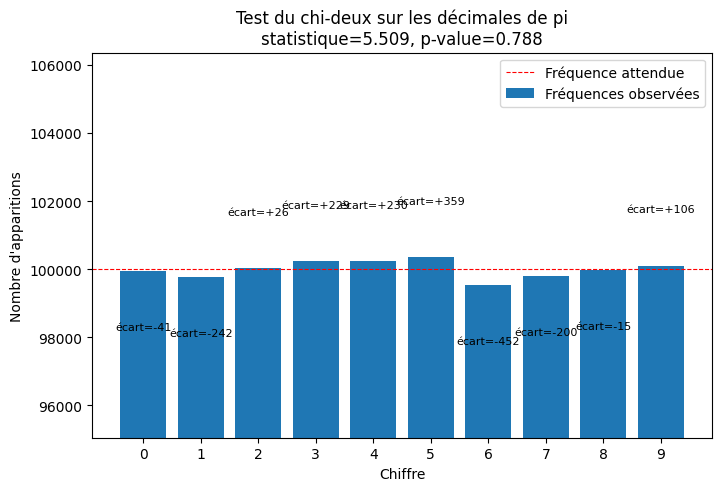

In [4]:
def plot_digit_frequencies(observed, expected, statistic, p_value):
    """Figure du chi-deux sur les chiffres, avec écarts et p-value."""
    digits_axis = list(range(10))
    expected_each = expected[0]
    n = sum(observed)
    offset = max(1, 0.0015 * n)

    plt.figure(figsize=(8, 5))
    plt.bar(digits_axis, observed, label="Fréquences observées")
    plt.axhline(expected_each, color="red", linestyle="--", linewidth=0.8, label="Fréquence attendue")

    for digit, count in enumerate(observed):
        difference = count - expected_each
        y = count + offset if difference >= 0 else count - offset
        va = "bottom" if difference >= 0 else "top"
        plt.text(digit, y, f"{difference:+.0f}", ha="center", va=va, fontsize=8)

    plt.xticks(digits_axis)
    plt.xlabel("Chiffre")
    plt.ylabel("Nombre d'apparitions")
    plt.title(f"Test du chi-deux sur les décimales de pi\nstatistique={statistic:.3f}, p-value={p_value:.3f}")
    plt.ylim(min(observed) - 3 * offset, max(observed) + 4 * offset)
    plt.legend()
    plt.savefig(FIGURES_DIR / "chi_squared.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_digit_frequencies(observed_digits, expected_digits, chi_stat, chi_p)

## 3. Gap test sur les chiffres

Le gap test étudie le nombre de chiffres observés entre deux occurrences successives d'un chiffre cible.

Si le chiffre cible apparaît avec probabilité $p=0.1$, alors sous indépendance :

$$
P(G=m)=p(1-p)^m.
$$

Dans le code, les grands écarts sont regroupés dans une dernière classe afin d'éviter des effectifs attendus trop petits avec la formule :
$$
P(G \ge m)=\sum_{k=18}^{+\infty} p(1-p)^{k} = (1-p)^{18}\sum_{k=0}^{+\infty} p(1-p)^{k} = (1-p)^m.
$$
car $$\sum_{k=0}^{+\infty} p(1-p)^{k} = p.\frac{1}{1-(1-p)} = p.\frac{1}{p} = 1$$

In [5]:
def gap_test_events(events, event_probability, max_gap=17):
    """Gap test générique pour une suite d'événements True/False."""
    gaps = []
    current_gap = 0
    found_first_event = False

    for event in events:
        if event:
            if found_first_event:
                gaps.append(current_gap)
            found_first_event = True
            current_gap = 0
        elif found_first_event:
            current_gap += 1

    observed = [0] * (max_gap + 2)
    for gap in gaps:
        if gap <= max_gap:
            observed[gap] += 1
        else:
            observed[-1] += 1

    n = len(gaps)
    expected = []
    for gap in range(max_gap + 1):
        expected.append(n * event_probability * ((1 - event_probability) ** gap))
    expected.append(n * ((1 - event_probability) ** (max_gap + 1)))

    statistic, p_value = chisquare(f_obs=observed, f_exp=expected)
    return observed, expected, statistic, p_value

def gap_test_digits(digits, target_digit, max_gap=17):
    events = [digit == target_digit for digit in digits]
    return gap_test_events(events, event_probability=0.1, max_gap=max_gap)

def plot_gap_test(observed, expected, max_gap, title, filepath):
    labels = [str(i) for i in range(max_gap + 1)] + [f"{max_gap + 1}+"]
    x_values = list(range(len(labels)))
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar([x - width / 2 for x in x_values], observed, width=width, label="Observés")
    plt.bar([x + width / 2 for x in x_values], expected, width=width, label="Attendus")
    plt.xticks(x_values, labels)
    plt.xlabel("Longueur de l'écart")
    plt.ylabel("Nombre d'observations")
    plt.title(title)
    plt.legend()
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.show()

Gap test pour le chiffre cible 7
Statistique = 14.763216
p-value = 0.678156
Conclusion: On ne rejette pas H0 au seuil de 5%.


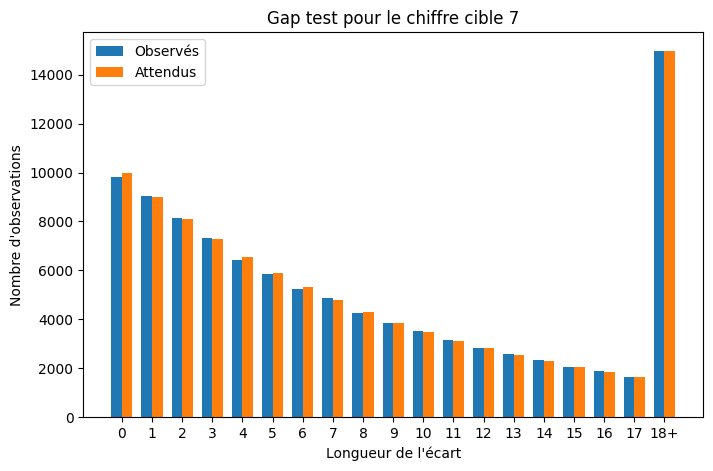

In [6]:
max_gap = 17
target_digit = 7
observed_gap, expected_gap, gap_stat, gap_p = gap_test_digits(digits, target_digit, max_gap)

print(f"Gap test pour le chiffre cible {target_digit}")
print(f"Statistique = {gap_stat:.6f}")
print(f"p-value = {gap_p:.6f}")
print("Conclusion:", conclusion(gap_p))

plot_gap_test(
    observed_gap,
    expected_gap,
    max_gap,
    title=f"Gap test pour le chiffre cible {target_digit}",
    filepath=FIGURES_DIR / f"gap_target_{target_digit}.png",
)

Chiffre | Statistique | p-value | Conclusion
0 | 14.700177 | 0.682441 | On ne rejette pas H0 au seuil de 5%.
1 | 23.184593 | 0.183596 | On ne rejette pas H0 au seuil de 5%.
2 | 16.180691 | 0.579938 | On ne rejette pas H0 au seuil de 5%.
3 | 6.055168 | 0.995968 | On ne rejette pas H0 au seuil de 5%.
4 | 31.183954 | 0.027408 | On rejette H0 au seuil de 5%.
5 | 18.317082 | 0.434955 | On ne rejette pas H0 au seuil de 5%.
6 | 11.365508 | 0.878208 | On ne rejette pas H0 au seuil de 5%.
7 | 14.763216 | 0.678156 | On ne rejette pas H0 au seuil de 5%.
8 | 16.384735 | 0.565716 | On ne rejette pas H0 au seuil de 5%.
9 | 25.550316 | 0.110493 | On ne rejette pas H0 au seuil de 5%.


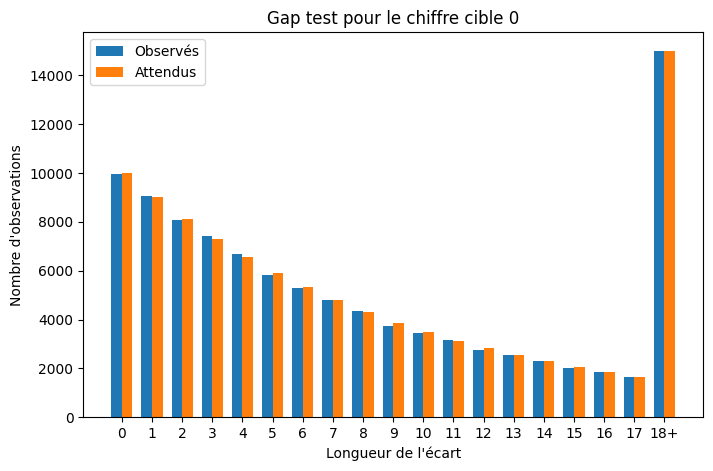

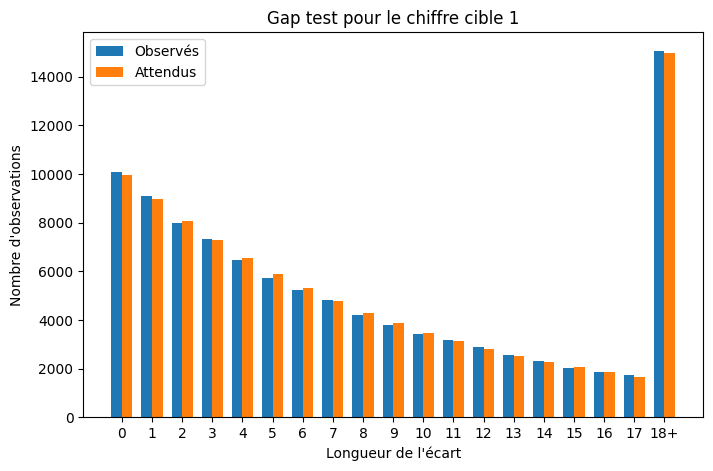

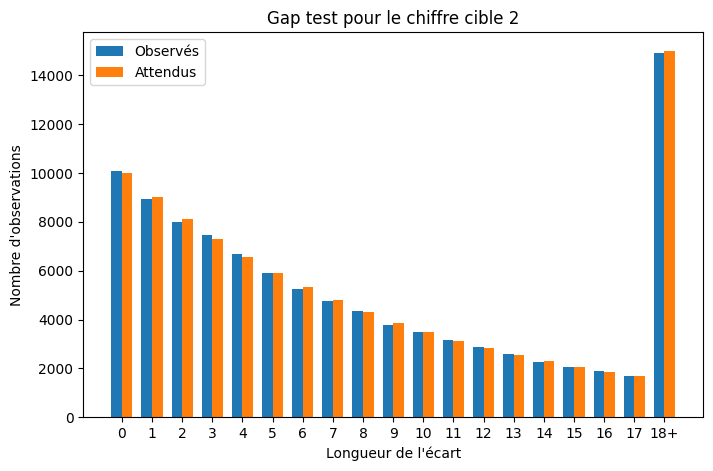

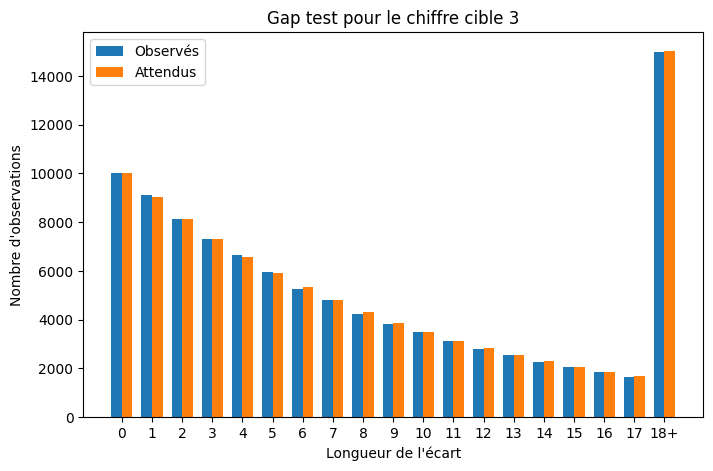

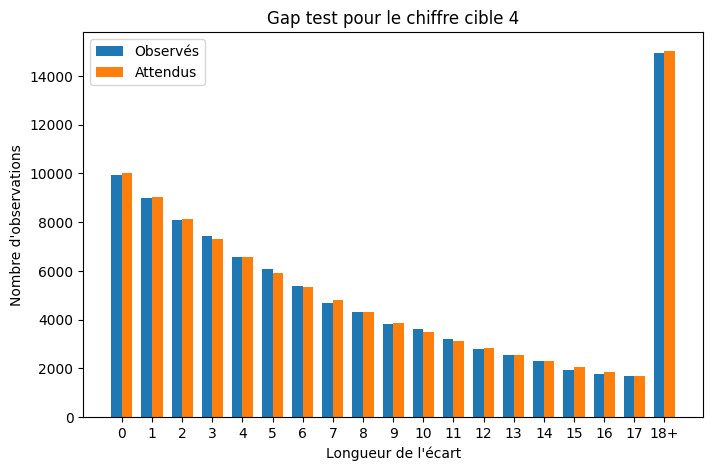

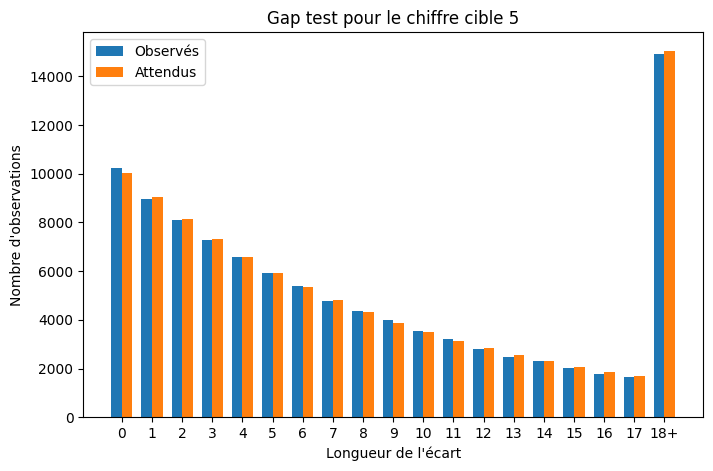

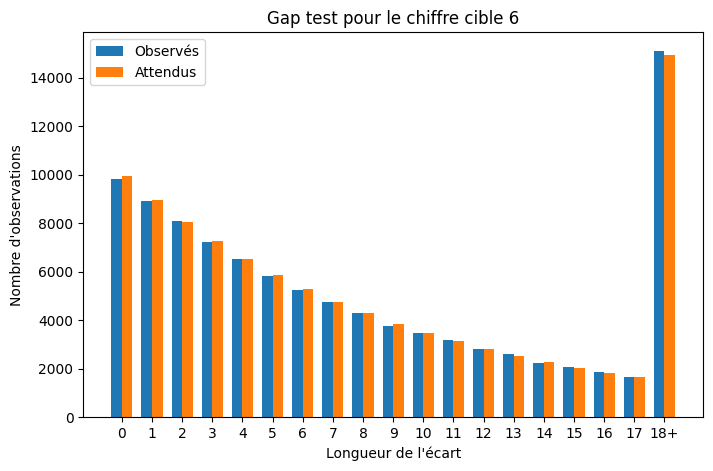

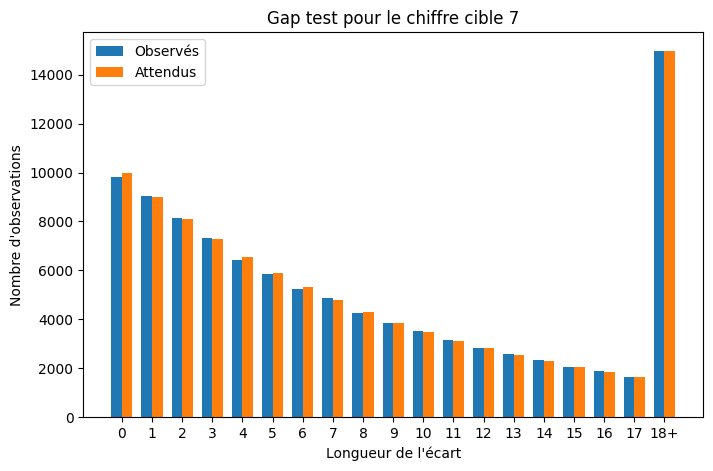

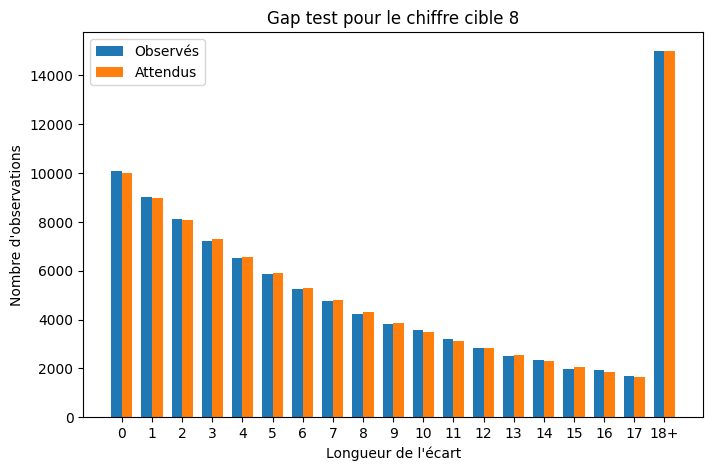

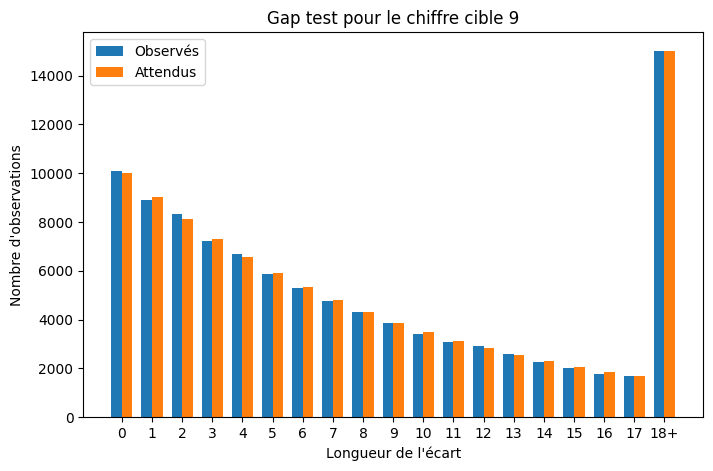

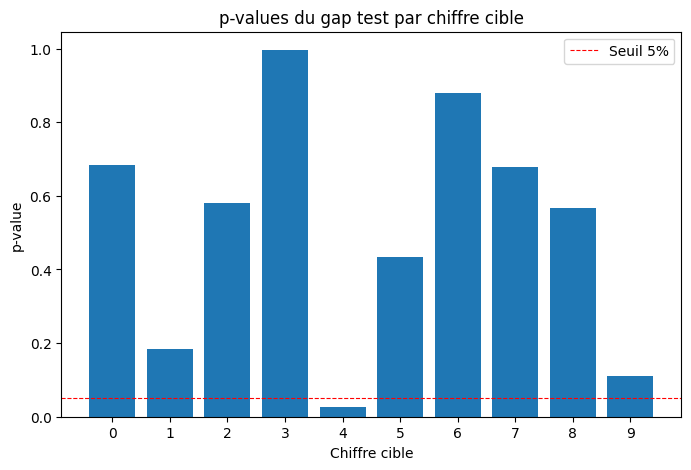

In [7]:
gap_results = []
for target in range(10):
    observed, expected, statistic, p_value = gap_test_digits(digits, target, max_gap)
    gap_results.append((target, observed, expected, statistic, p_value))

print("Chiffre | Statistique | p-value | Conclusion")
for target, observed, expected, statistic, p_value in gap_results:
    print(f"{target} | {statistic:.6f} | {p_value:.6f} | {conclusion(p_value)}")

targets = [row[0] for row in gap_results]
p_values = [row[4] for row in gap_results]

for target, observed, expected, statistic, p_value in gap_results:
    plot_gap_test(
        observed,
        expected,
        max_gap,
        title=f"Gap test pour le chiffre cible {target}",
        filepath=FIGURES_DIR / "gap_tests" / f"gap_target_{target}.png",
    )

plt.figure(figsize=(8, 5))
plt.bar(targets, p_values)
plt.axhline(ALPHA, color="red", linestyle="--", linewidth=0.8, label="Seuil 5%")
plt.xticks(targets)
plt.xlabel("Chiffre cible")
plt.ylabel("p-value")
plt.title("p-values du gap test par chiffre cible")
plt.legend()
plt.savefig(FIGURES_DIR / "gap_tests" / "gap_pvalues_by_target.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Générateur uniforme construit à partir de $\pi$

On découpe les décimales en blocs non chevauchants de taille $k$.

Pour un bloc $d_1d_2\ldots d_k$, on construit :

$$
B = \sum_{j=1}^{k} d_j 10^{k-j}
$$

puis :

$$
U = \frac{B}{10^k}.
$$

Ainsi, $U \in [0,1[$. Cette construction est volontairement simple.

In [8]:
def pi_uniform_generator(digits, block_size):
    """Transforme les décimales de pi en valeurs de [0,1[ par blocs non chevauchants."""
    values = []
    number_of_blocks = len(digits) // block_size

    for i in range(number_of_blocks):
        block = digits[i * block_size : (i + 1) * block_size]
        integer_value = 0
        for digit in block:
            integer_value = 10 * integer_value + digit
        values.append(integer_value / (10 ** block_size))

    return values

block_size = 6
pi_values = pi_uniform_generator(digits, block_size)
print(f"k = {block_size}")
print(f"Nombre de valeurs générées = {len(pi_values)}")
print(pi_values[:5])

k = 6
Nombre de valeurs générées = 166666
[0.141592, 0.653589, 0.793238, 0.462643, 0.383279]


## 5. Tests pour des valeurs dans $[0,1[$

Pour les générateurs, on utilise trois tests :

1. $\chi^2$ sur dix classes de même largeur dans $[0,1[$ ;
2. Kolmogorov--Smirnov contre la loi uniforme continue ;
3. gap test sur l'événement $0.2 \leq U < 0.3$.

Pour le test du $\chi^2$, les classes sont :

$$
[0,0.1[, [0.1,0.2[, \ldots, [0.9,1[.
$$
Note:
Le cas k=1 constitue un cas particulier où le générateur produit uniquement les valeurs 0.0,0.1,…,0.9. Le test de Kolmogorov–Smirnov y est donc moins adapté puisque la distribution est fortement discrète. Néanmoins, ce cas reste intéressant car il établit un lien direct entre l’étude des décimales de π et celle du générateur construit à partir de ces décimales.

In [9]:
def chi_squared_uniform(values, number_of_classes=10):
    """Chi-deux sur des classes de même largeur de [0,1[."""
    observed = [0] * number_of_classes
    for value in values:
        index = int(value * number_of_classes)
        if index == number_of_classes:
            index = number_of_classes - 1
        observed[index] += 1

    expected = [len(values) / number_of_classes] * number_of_classes
    statistic, p_value = chisquare(f_obs=observed, f_exp=expected)
    return observed, expected, statistic, p_value

def ks_uniform(values):
    """Kolmogorov-Smirnov contre la loi uniforme sur [0,1[."""
    statistic, p_value = kstest(values, "uniform")
    return statistic, p_value

def gap_test_uniform(values, interval_start=0.2, interval_end=0.3, max_gap=17):
    """Gap test sur l'événement interval_start <= U < interval_end."""
    events = [interval_start <= value < interval_end for value in values]
    return gap_test_events(events, event_probability=interval_end - interval_start, max_gap=max_gap)

def print_uniform_tests(name, values):
    print(f"Tests pour {name}")

    observed, expected, statistic, p_value = chi_squared_uniform(values)
    print(f"Chi-deux : statistique={statistic:.6f}, p-value={p_value:.6f}, {conclusion(p_value)}")

    statistic, p_value = ks_uniform(values)
    print(f"KS       : statistique={statistic:.6f}, p-value={p_value:.6f}, {conclusion(p_value)}")

    observed, expected, statistic, p_value = gap_test_uniform(values)
    print(f"Gap test : statistique={statistic:.6f}, p-value={p_value:.6f}, {conclusion(p_value)}")

In [10]:
print_uniform_tests("générateur pi", pi_values)

Tests pour générateur pi
Chi-deux : statistique=5.138205, p-value=0.822098, On ne rejette pas H0 au seuil de 5%.
KS       : statistique=0.001343, p-value=0.924282, On ne rejette pas H0 au seuil de 5%.
Gap test : statistique=12.855109, p-value=0.800108, On ne rejette pas H0 au seuil de 5%.


## 6. Influence de la taille des blocs

Le test KS est appliqué pour plusieurs valeurs de $k$.

Remarque importante : pour $k=1$ ou $k=2$, les valeurs possibles sont peu nombreuses. Le générateur produit alors une distribution très discrète, alors que le test KS compare à une loi uniforme continue. Il faut donc interpréter ces petits $k$ avec prudence.

k | valeurs | statistique KS | p-value | conclusion
1 | 1000000 | 0.100561 | 0.000000 | On rejette H0 au seuil de 5%.
2 | 500000 | 0.011114 | 0.000000 | On rejette H0 au seuil de 5%.
3 | 333333 | 0.001319 | 0.607658 | On ne rejette pas H0 au seuil de 5%.
4 | 250000 | 0.001508 | 0.619877 | On ne rejette pas H0 au seuil de 5%.
5 | 200000 | 0.001645 | 0.650701 | On ne rejette pas H0 au seuil de 5%.
6 | 166666 | 0.001343 | 0.924282 | On ne rejette pas H0 au seuil de 5%.
7 | 142857 | 0.003969 | 0.022164 | On rejette H0 au seuil de 5%.
8 | 125000 | 0.001586 | 0.911302 | On ne rejette pas H0 au seuil de 5%.
9 | 111111 | 0.003106 | 0.233626 | On ne rejette pas H0 au seuil de 5%.


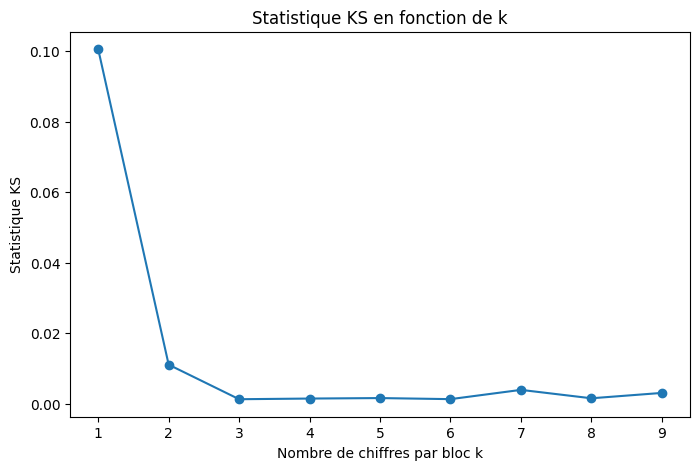

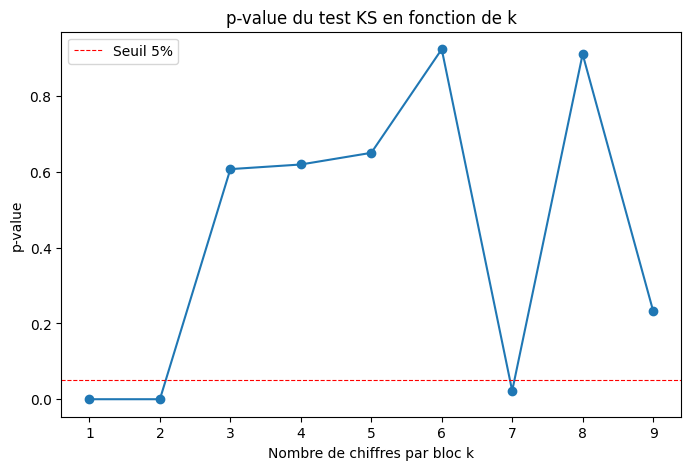

In [11]:
ks_results = []
for k in range(1, 10):
    values = pi_uniform_generator(digits, k)
    statistic, p_value = ks_uniform(values)
    ks_results.append((k, len(values), statistic, p_value))

print("k | valeurs | statistique KS | p-value | conclusion")
for k, n_values, statistic, p_value in ks_results:
    print(f"{k} | {n_values} | {statistic:.6f} | {p_value:.6f} | {conclusion(p_value)}")

k_values = [row[0] for row in ks_results]
statistics = [row[2] for row in ks_results]
p_values = [row[3] for row in ks_results]

plt.figure(figsize=(8, 5))
plt.plot(k_values, statistics, marker="o")
plt.xticks(k_values)
plt.xlabel("Nombre de chiffres par bloc k")
plt.ylabel("Statistique KS")
plt.title("Statistique KS en fonction de k")
plt.savefig(FIGURES_DIR / "ks_statistic_by_k.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(k_values, p_values, marker="o")
plt.axhline(ALPHA, color="red", linestyle="--", linewidth=0.8, label="Seuil 5%")
plt.xticks(k_values)
plt.xlabel("Nombre de chiffres par bloc k")
plt.ylabel("p-value")
plt.title("p-value du test KS en fonction de k")
plt.legend()
plt.savefig(FIGURES_DIR / "ks_pvalue_by_k.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Comparaison avec `random.random()` de Python

On génère le même nombre de valeurs avec Python qu'avec le générateur basé sur $\pi$. La graine est fixée pour rendre les résultats reproductibles.

In [12]:
random.seed(12345)
python_values = [random.random() for _ in range(len(pi_values))]

print_uniform_tests("générateur Python", python_values)

Tests pour générateur Python
Chi-deux : statistique=9.987304, p-value=0.351514, On ne rejette pas H0 au seuil de 5%.
KS       : statistique=0.003078, p-value=0.084912, On ne rejette pas H0 au seuil de 5%.
Gap test : statistique=14.745893, p-value=0.679335, On ne rejette pas H0 au seuil de 5%.


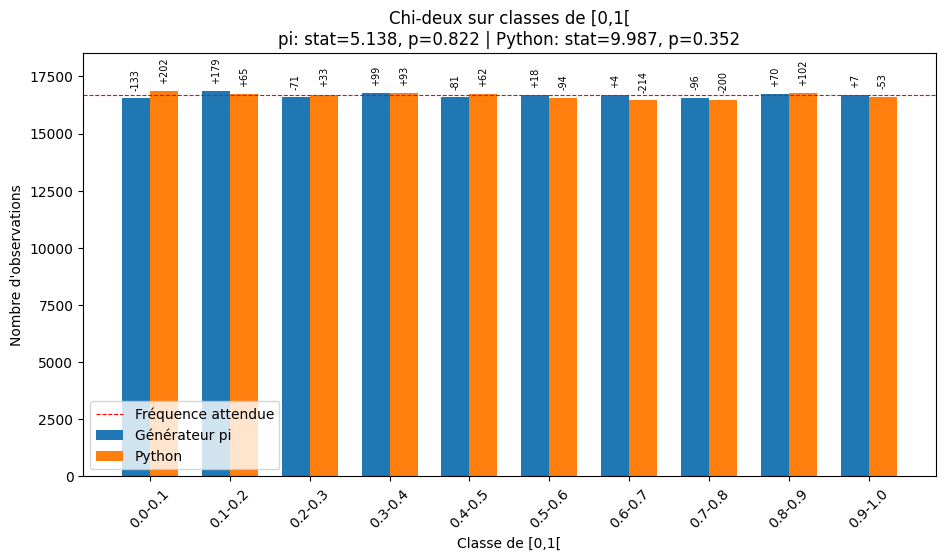

In [13]:
def plot_generator_chi_squared_comparison(pi_values, python_values):
    pi_observed, pi_expected, pi_statistic, pi_p = chi_squared_uniform(pi_values)
    py_observed, py_expected, py_statistic, py_p = chi_squared_uniform(python_values)

    classes = list(range(10))
    labels = [f"{i/10:.1f}-{(i+1)/10:.1f}" for i in classes]
    width = 0.35
    pi_positions = [x - width / 2 for x in classes]
    py_positions = [x + width / 2 for x in classes]
    offset = max(1, 0.002 * len(pi_values))

    plt.figure(figsize=(11, 5.5))
    plt.bar(pi_positions, pi_observed, width=width, label="Générateur pi")
    plt.bar(py_positions, py_observed, width=width, label="Python")
    plt.axhline(pi_expected[0], color="red", linestyle="--", linewidth=0.8, label="Fréquence attendue")

    for position, count in zip(pi_positions, pi_observed):
        plt.text(position, count + offset, f"{count - pi_expected[0]:+.0f}", ha="center", va="bottom", rotation=90, fontsize=7)
    for position, count in zip(py_positions, py_observed):
        plt.text(position, count + offset, f"{count - py_expected[0]:+.0f}", ha="center", va="bottom", rotation=90, fontsize=7)

    plt.xticks(classes, labels, rotation=45)
    plt.xlabel("Classe de [0,1[")
    plt.ylabel("Nombre d'observations")
    plt.title(f"Chi-deux sur classes de [0,1[\npi: stat={pi_statistic:.3f}, p={pi_p:.3f} | Python: stat={py_statistic:.3f}, p={py_p:.3f}")
    plt.ylim(0, max(max(pi_observed), max(py_observed)) + 5 * offset)
    plt.legend()
    plt.savefig(FIGURES_DIR / "comparison_chi_squared_uniform.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_generator_chi_squared_comparison(pi_values, python_values)

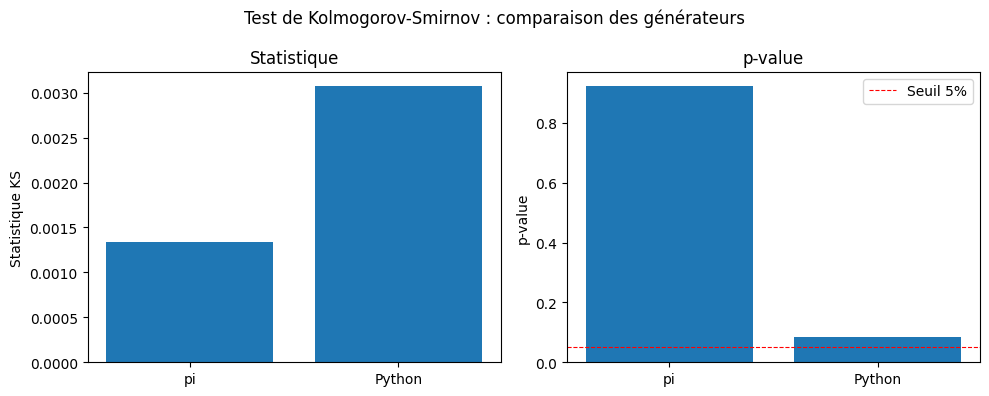

In [14]:
def plot_generator_ks_comparison(pi_values, python_values):
    labels = ["pi", "Python"]
    pi_stat, pi_p = ks_uniform(pi_values)
    py_stat, py_p = ks_uniform(python_values)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].bar(labels, [pi_stat, py_stat])
    axes[0].set_ylabel("Statistique KS")
    axes[0].set_title("Statistique")

    axes[1].bar(labels, [pi_p, py_p])
    axes[1].axhline(ALPHA, color="red", linestyle="--", linewidth=0.8, label="Seuil 5%")
    axes[1].set_ylabel("p-value")
    axes[1].set_title("p-value")
    axes[1].legend()

    fig.suptitle("Test de Kolmogorov-Smirnov : comparaison des générateurs")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "comparison_ks_uniform.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_generator_ks_comparison(pi_values, python_values)

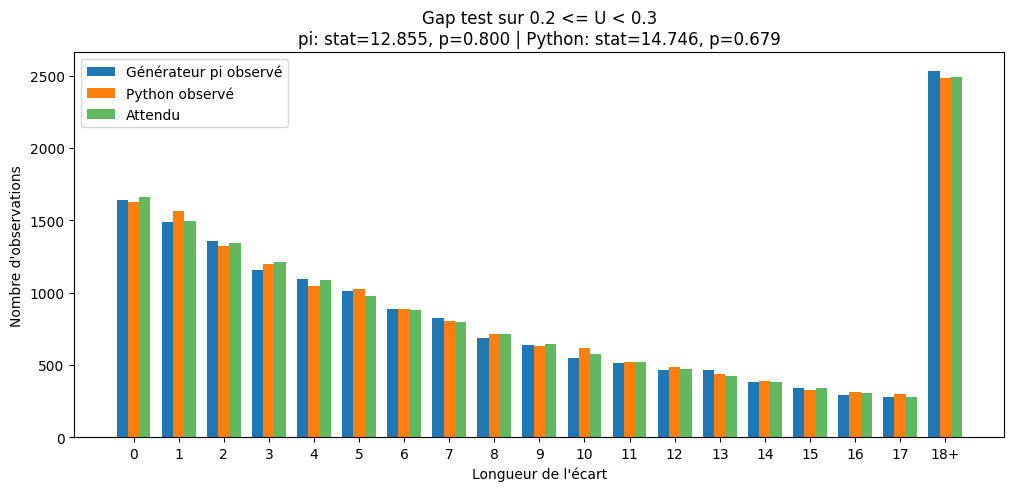

In [15]:
def plot_generator_gap_comparison(pi_values, python_values):
    max_gap = 17
    interval_start = 0.2
    interval_end = 0.3

    pi_observed, pi_expected, pi_stat, pi_p = gap_test_uniform(pi_values, interval_start, interval_end, max_gap)
    py_observed, py_expected, py_stat, py_p = gap_test_uniform(python_values, interval_start, interval_end, max_gap)

    labels = [str(i) for i in range(max_gap + 1)] + [f"{max_gap + 1}+"]
    x_values = list(range(len(labels)))
    width = 0.25

    plt.figure(figsize=(12, 5))
    plt.bar([x - width for x in x_values], pi_observed, width=width, label="Générateur pi observé")
    plt.bar(x_values, py_observed, width=width, label="Python observé")
    plt.bar([x + width for x in x_values], pi_expected, width=width, label="Attendu", alpha=0.75)
    plt.xticks(x_values, labels)
    plt.xlabel("Longueur de l'écart")
    plt.ylabel("Nombre d'observations")
    plt.title(f"Gap test sur {interval_start:.1f} <= U < {interval_end:.1f}\npi: stat={pi_stat:.3f}, p={pi_p:.3f} | Python: stat={py_stat:.3f}, p={py_p:.3f}")
    plt.legend()
    plt.savefig(FIGURES_DIR / "comparison_gap_uniform.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_generator_gap_comparison(pi_values, python_values)

## 8. Interprétation finale

Les p-values doivent être interprétées avec prudence :

- si la p-value est inférieure à $5\%$, on rejette $H_0$ au seuil choisi ;
- sinon, on ne rejette pas $H_0$ ; cela signifie seulement que les observations sont compatibles avec $H_0$ pour ce test.

Le rejet observé pour le chiffre cible 4 dans le gap test peut s'expliquer par le fait que plusieurs tests sont réalisés simultanément. Avec dix chiffres cibles, il est plausible d'obtenir ponctuellement une p-value inférieure à $5\%$ même si les résultats sont globalement compatibles avec le modèle. La grande taille de l'échantillon rend aussi les tests sensibles à de petits écarts.

La comparaison avec `random.random()` montre que, pour les tests utilisés et l'échantillon étudié, le générateur basé sur $\pi$ donne des résultats compatibles avec une loi uniforme sur $[0,1[$.